# Customer Churn Prediction

## Problem Statement
Customer churn is one of the biggest challenges in the banking industry.
Losing a customer is far more costly than acquiring a new one.
The goal of this project is to build a machine learning model that predicts
whether a bank customer will leave (churn) or stay, based on their profile
and banking behavior.

## Objective
- Identify key factors that influence customer churn
- Build and compare multiple classification models
- Select the best performing model for deployment

## Dataset
The dataset contains 10,000 bank customers with 14 features including
credit score, geography, gender, age, tenure, balance, and more.
The target variable is `Exited` (1 = churned, 0 = stayed).

## Approach
1. Data Loading & Overview
2. Data Cleaning & Null Value Analysis
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Preprocessing
5. Model Training & Evaluation
6. Model Comparison
7. Save Best Model

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
print('shape',df.shape)
print('first 5 rows', df.head())

shape (10000, 14)
first 5 rows    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         9

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df = df.drop(columns=['RowNumber','CustomerId','Surname'])
print("Shape after dropping irrelevant columns:", df.shape)
print("\nRemaining columns:", list(df.columns))

Shape after dropping irrelevant columns: (10000, 11)

Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [8]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


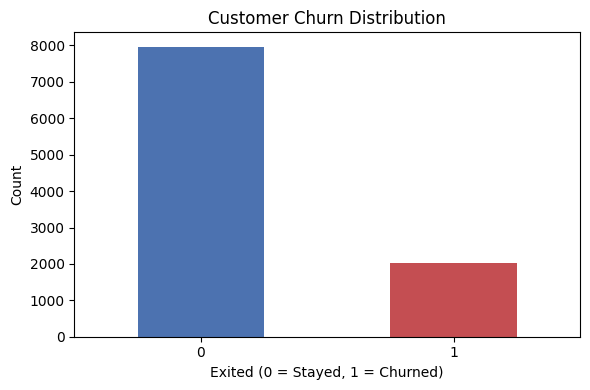

Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37 %


In [9]:
# Churn distribution
plt.figure(figsize=(6,4))
df['Exited'].value_counts().plot(kind='bar', color=['#4C72B0','#C44E52'])
plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df['Exited'].value_counts())
print("\nChurn Rate:", round(df['Exited'].mean() * 100, 2), "%")

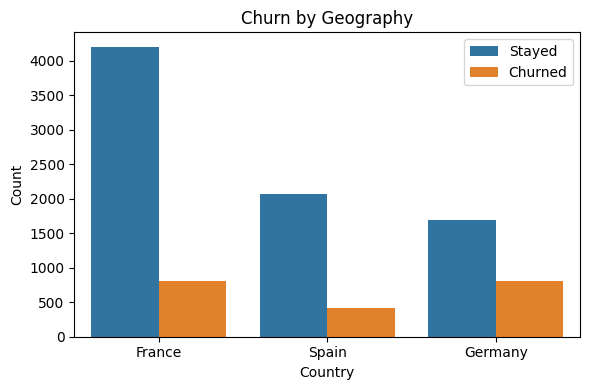

In [10]:
# Churn by Geography
plt.figure(figsize=(6,4))
sns.countplot(x='Geography', data = df,  hue='Exited')
plt.title('Churn by Geography')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

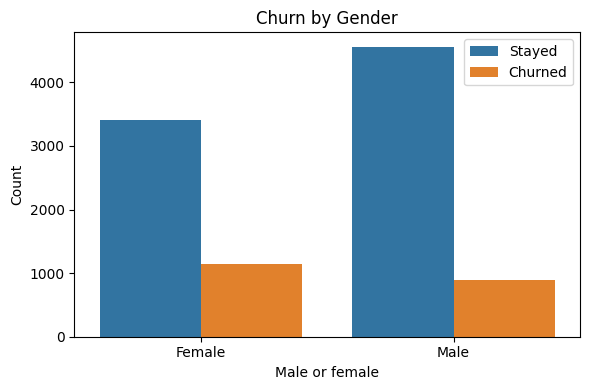

In [11]:
# Churn by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data = df,  hue='Exited')
plt.title('Churn by Gender')
plt.xlabel('Male or female')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

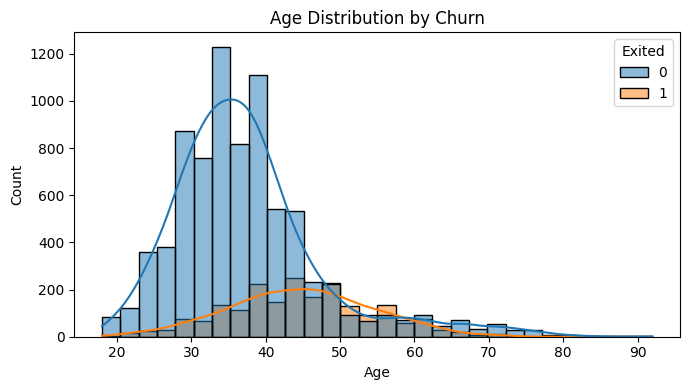

In [12]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True)
plt.title('Age Distribution by Churn')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

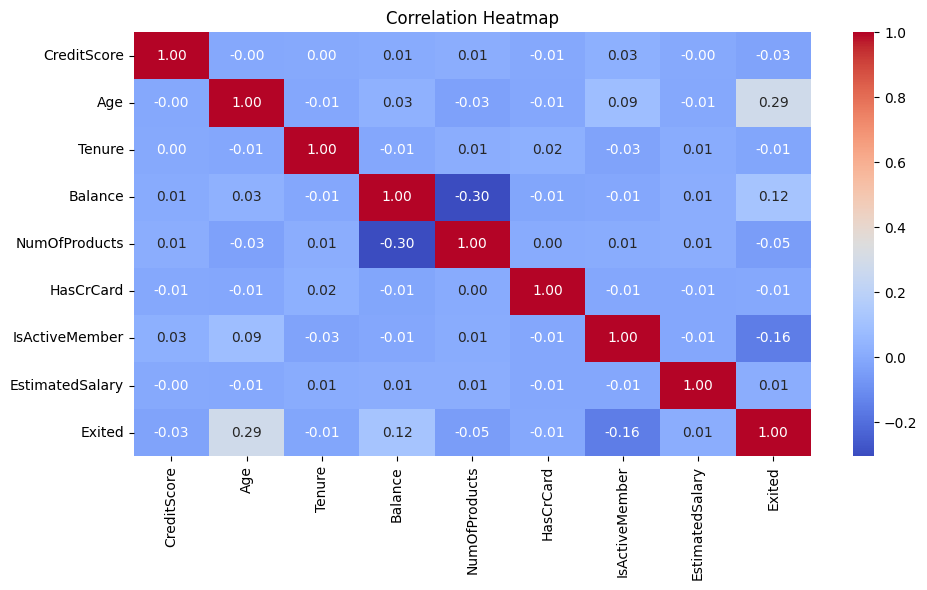

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Encode Gender and Geography
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

# Geography has 3 categories so use get_dummies
df = pd.get_dummies(df, columns=['Geography'], drop_first=False)

print("Columns after encoding:")
print(list(df.columns))
df.head()

Columns after encoding:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,True,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,False,True


In [15]:

X = df.drop(columns=['Exited'])
y = df['Exited']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:\n", y.value_counts())

Features shape: (10000, 12)
Target shape: (10000,)

Target distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64


In [16]:
!pip install imbalanced-learn

In [17]:
# Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {0: 7963, 1: 2037}
After SMOTE: {1: 7963, 0: 7963}


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (12740, 12)
X_test: (3186, 12)


In [19]:
# Scale numerical features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train,y_train)
lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", round(lr_acc * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 81.83 %

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.82      1593
           1       0.84      0.78      0.81      1593

    accuracy                           0.82      3186
   macro avg       0.82      0.82      0.82      3186
weighted avg       0.82      0.82      0.82      3186



In [22]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", round(dt_acc * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))


Decision Tree Accuracy: 80.79 %

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1593
           1       0.80      0.82      0.81      1593

    accuracy                           0.81      3186
   macro avg       0.81      0.81      0.81      3186
weighted avg       0.81      0.81      0.81      3186



In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy      :", round(rf_acc * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy      : 87.76 %

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1593
           1       0.89      0.86      0.88      1593

    accuracy                           0.88      3186
   macro avg       0.88      0.88      0.88      3186
weighted avg       0.88      0.88      0.88      3186



In [24]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)
print("Gradient Boosting Accuracy  :", round(gb_acc * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy  : 86.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1593
           1       0.88      0.84      0.86      1593

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.86      3186
weighted avg       0.87      0.87      0.86      3186



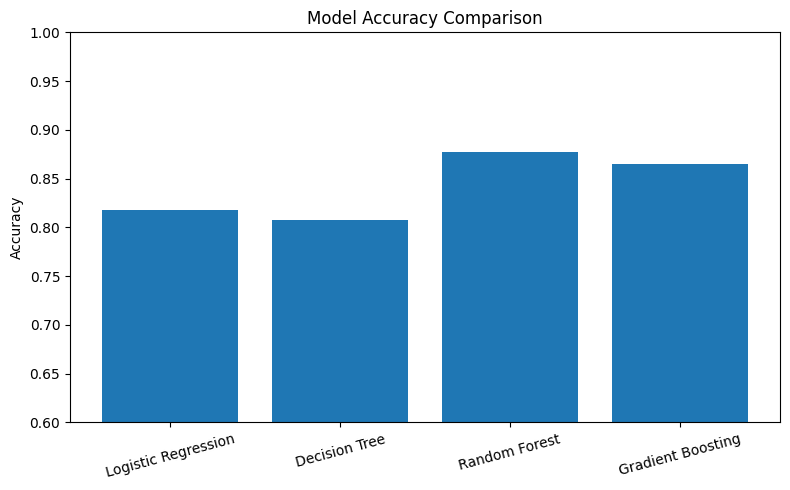

In [25]:
# Simple bar chart
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
accuracies = [lr_acc, dt_acc, rf_acc, gb_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.ylim(0.6, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [26]:
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])
dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
gb_auc = roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1])
print("Best model selection based on ROC AUC:")
print("Logistic Regression ROC AUC:", round(lr_auc * 100, 2), "%")
print("Decision Tree ROC AUC      :", round(dt_auc * 100, 2), "%")
print("Random Forest ROC AUC      :", round(rf_auc * 100, 2), "%")
print("Gradient Boosting ROC AUC  :", round(gb_auc * 100, 2), "%")

Best model selection based on ROC AUC:
Logistic Regression ROC AUC: 89.54 %
Decision Tree ROC AUC      : 80.79 %
Random Forest ROC AUC      : 94.48 %
Gradient Boosting ROC AUC  : 93.96 %


In [27]:
import pickle
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [28]:
with open ('churn_model.pkl','wb') as f:
    pickle.dump(rf_model,f)
with open ('scaler.pkl','wb') as f:
    pickle.dump(scaler,f)
    
print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [30]:
with open('churn_model.pkl','rb') as f:
    loaded_scaler = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)   

##  Project Summary & Conclusions

### What We Did
- Loaded a bank customer dataset with 10,000 rows and 14 columns.
- Dropped irrelevant columns (RowNumber, CustomerId, Surname).
- Checked for null values and duplicates — dataset was clean.
- Encoded categorical columns (Gender, Geography) for model compatibility.
- Handled class imbalance using SMOTE — dataset was biased towards non-churned customers.
- Scaled numerical features using StandardScaler.
- Trained 4 classification models individually and compared them.

### What We Observed During EDA
- Overall churn rate was around 20% — meaning 1 in 5 customers left the bank.
- Germany had the highest churn rate compared to France and Spain.
- Female customers churned more than male customers.
- Older customers (40-60 age group) were more likely to churn.
- Customers with fewer products (1 or 2) had higher churn tendency.
- Balance and Age showed the strongest correlation with churn.

### Model Results
| Model | ROC AUC |
|---|---|
| Logistic Regression | 89.54% |
| Decision Tree | 80.79% |
| Random Forest | 94.48% |
| Gradient Boosting | 93.96% |

### Why Random Forest Performed Best
- Random Forest builds multiple decision trees and combines their results which reduces overfitting compared to a single Decision Tree.
- It handles both numerical and categorical features well.
- It captures complex non-linear relationships between features which Logistic Regression cannot do.
- It is less sensitive to outliers in the data.

### Why Decision Tree Performed Worst
- A single Decision Tree tends to overfit the training data.
- It memorizes patterns rather than learning general rules.
- Random Forest fixes this by averaging many trees together.

### Key Takeaways
- Class imbalance was a major challenge — SMOTE helped balance it.
- Age, Balance and Geography were the most important features.
- Random Forest with 94.48% ROC AUC is the best model for deployment.
- The model can help banks identify at-risk customers early and take action to retain them.

### Future Improvements
- We can try XGBoost or LightGBM for potentially better performance.
- We can collect more data on customer complaints and support interactions.
- We can deploy as a full web application with a database backend.